In [1]:
import numpy as np
import sys
import os

# 1. Import your Fortran reflectivity calculator
sys.path.append(os.path.join(os.getcwd(), "src"))
sys.path.append(os.path.join(os.getcwd(), "../src"))
sys.path.append(os.path.join(os.getcwd(), "../src/fortran"))
sys.path.append(os.path.join(os.getcwd(), "../src/runners"))
from cletkf_wloc import common_da as cda

# 2. Create the vectorized version for fast processing
vectorized_calc_ref = np.vectorize(cda.calc_ref)

# 3. Define the helper function
def get_ens_h_of_x(state_ensemble, ox, oy, oz, var_idx):
    """
    Calculates H(x) (reflectivity) for all members at obs locations.
    
    Args:
        state_ensemble: (nx, ny, nz, Ne, nvar) array (like d1['xa'])
        ox, oy, oz: 1D arrays of obs grid indices (n_obs,)
        var_idx: Dictionary mapping variable names to indices
        
    Returns:
        h_of_x: (n_obs, Ne) array of reflectivities
    """
    # Extract state variables for all members at the specific obs points
    # Shape of ens_at_obs: (n_obs, Ne, nvar)
    ens_at_obs = state_ensemble[ox, oy, oz, :, :]

    # Extract the specific microphysics and thermodynamics variables
    qr = ens_at_obs[..., var_idx['qr']] 
    qs = ens_at_obs[..., var_idx['qs']]
    qg = ens_at_obs[..., var_idx['qg']]
    TT = ens_at_obs[..., var_idx['T']]
    PP = ens_at_obs[..., var_idx['P']]
    
    # Calculate reflectivity for all obs/members at once
    h_of_x = vectorized_calc_ref(qr, qs, qg, TT, PP).astype(np.float32)
    
    return h_of_x

# ❗ Also make sure your VAR_IDX dictionary is defined in the notebook!
VAR_IDX = {
    'qr': 0, 'qs': 1, 'qg': 2, 'T': 3, 'P': 4,
    'u': 5, 'v': 6, 'w': 7
}

Loading strided data...
Calculating final H(xa) for 1-iter...
Calculating final H(xa) for 2-iter...
Calculating final H(xa) for 3-iter...
Final analysis departures calculated successfully!
Generating plot...


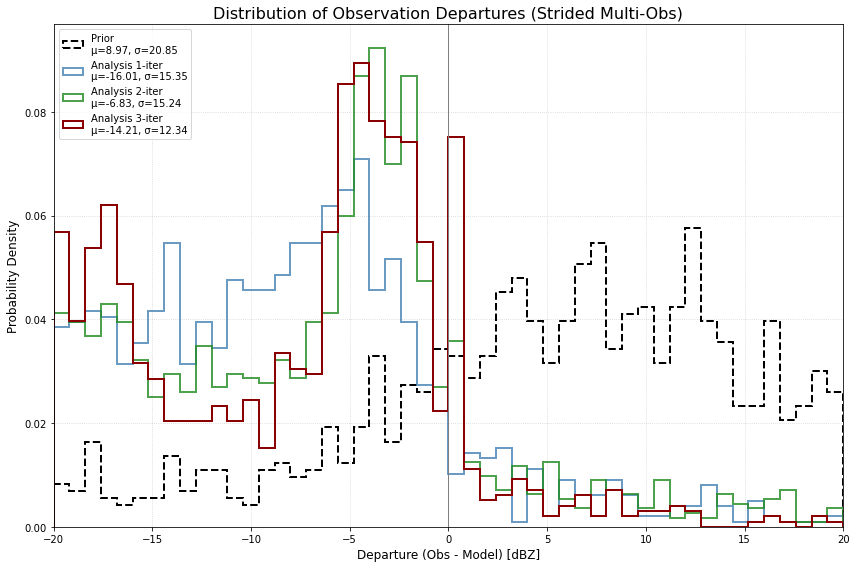

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

#----------------------------------------------------------------------
## 1. USER CONFIGURATION
#----------------------------------------------------------------------
# Point to the exact directory your script just created
base_path = "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/WS2/"

# Use the exact filenames from your cluster log
file_1 = os.path.join(base_path, "WS2_TEnKF_Nt01_as2_Lx5Ly5Lz2_Ne040_strstr5_qcE_True00.npz")
file_2 = os.path.join(base_path, "WS2_TEnKF_Nt02_as2_Lx5Ly5Lz2_Ne040_strstr5_qcE_True00.npz")
file_3 = os.path.join(base_path, "WS2_TEnKF_Nt03_as2_Lx5Ly5Lz2_Ne040_strstr5_qcE_True00.npz")

#----------------------------------------------------------------------
## 2. LOAD DATA & EXTRACT DEPARTURES
#----------------------------------------------------------------------
print("Loading strided data...")
d1 = np.load(file_1)
d2 = np.load(file_2)
d3 = np.load(file_3)

# 1. The prior departure (O-B) is identical for all, saved as 'dep'
deps_prior = d1['dep']

# 2. Extract locations and truth observations
ox, oy, oz = d1['ox'], d1['oy'], d1['oz']
yo = d1['yo']

# 3. Calculate the TRUE final Analysis departures (O-A) 
# using the get_ens_h_of_x function you already wrote!
print("Calculating final H(xa) for 1-iter...")
hxa_1 = get_ens_h_of_x(d1['xa'], ox, oy, oz, VAR_IDX)
deps_1 = yo - hxa_1.mean(axis=1)

print("Calculating final H(xa) for 2-iter...")
hxa_2 = get_ens_h_of_x(d2['xa'], ox, oy, oz, VAR_IDX)
deps_2 = yo - hxa_2.mean(axis=1)

print("Calculating final H(xa) for 3-iter...")
hxa_3 = get_ens_h_of_x(d3['xa'], ox, oy, oz, VAR_IDX)
deps_3 = yo - hxa_3.mean(axis=1)

print("Final analysis departures calculated successfully!")
#----------------------------------------------------------------------
## 3. CREATE THE PLOT
#----------------------------------------------------------------------
print("Generating plot...")

hist_bins = 50
hist_range = (-20, 20) 

fig, ax = plt.subplots(figsize=(12, 8))

# Prior
ax.hist(deps_prior, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2,
        label=f'Prior \nμ={deps_prior.mean():.2f}, σ={deps_prior.std():.2f}', 
        color='black', linestyle='--')

# 1-Iteration
ax.hist(deps_1, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2,
        label=f'Analysis 1-iter \nμ={deps_1.mean():.2f}, σ={deps_1.std():.2f}', 
        color='SteelBlue', alpha=0.8)

# 2-Iterations
ax.hist(deps_2, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2,
        label=f'Analysis 2-iter \nμ={deps_2.mean():.2f}, σ={deps_2.std():.2f}', 
        color='ForestGreen', alpha=0.8)

# 3-Iterations
ax.hist(deps_3, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2, 
        label=f'Analysis 3-iter \nμ={deps_3.mean():.2f}, σ={deps_3.std():.2f}', 
        color='DarkRed', alpha=1.0)

# Formatting
ax.set_title('Distribution of Observation Departures (Strided Multi-Obs)', fontsize=16)
ax.set_xlabel('Departure (Obs - Model) [dBZ]', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(hist_range) 
ax.axvline(0, color='gray', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

In [35]:
import numpy as np

def calculate_implied_ess(departures, obs_error_var):
    """
    Calculates the Effective Sample Size (ESS) for an ensemble.
    
    Args:
        departures: Array of (Obs - Background) with shape (n_obs, Ne)
        obs_error_var: The scalar observation error variance (e.g., 5.0)
        
    Returns:
        ess: Array of shape (n_obs,) containing the ESS for each observation.
    """
    # 1. Calculate the raw likelihood weights for each member
    # w = exp( -0.5 * (departure^2) / R )
    weights = np.exp(-0.5 * (departures**2) / obs_error_var)
    
    # 2. Normalize the weights across the ensemble axis so they sum to 1
    # Adding a tiny epsilon to prevent division by zero
    weights_sum = np.sum(weights, axis=1, keepdims=True) + 1e-12
    
    normalized_weights = weights / weights_sum
    print(f"min weight: {normalized_weights.min():.4e}, max weight: {normalized_weights.max():.4e}, sum of weights (should be 1): {normalized_weights.sum(axis=1)}")
    # 3. Calculate ESS: 1 / sum(W^2)
    ess = 1.0 / np.sum(normalized_weights**2, axis=1)
    
    return ess

In [8]:
yo[:, None].shape

(1893, 1)

In [10]:
d1['hxfs'][0].shape

(1893, 40)

In [11]:
deps_prior_all.shape

(1893, 40)

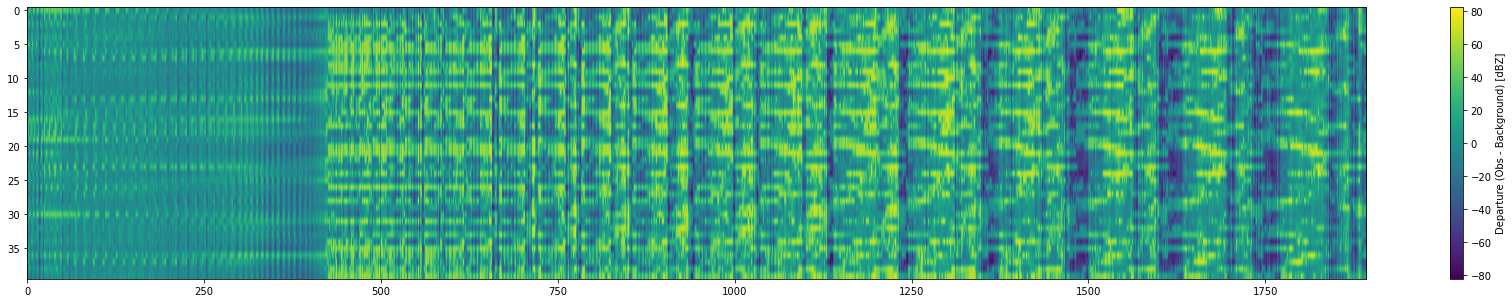

In [26]:
fig, ax = plt.subplots(figsize=(30, 5))
ax.imshow(deps_prior_all.T, aspect='auto')
# cbar
fig.colorbar(ax.images[0], ax=ax, orientation='vertical', label='Departure (Obs - Background) [dBZ]')
plt.show()

In [36]:
print("\nCalculating Effective Sample Size (ESS)...")
obs_error_var = 5.0 # Set this to match your config!

# 1. Prior ESS (Using the saved hxfs array from step 0)
# d1['hxfs'][0] has shape (n_obs, Ne). yo has shape (n_obs,). 
# We use yo[:, None] to broadcast the subtraction across all 40 members.
deps_prior_all = yo[:, None] - d1['hxfs'][0] 
ess_prior = calculate_implied_ess(deps_prior_all, obs_error_var)

# 2. Analysis ESS for 1-Iter and 3-Iter
# You already calculated hxa_1 and hxa_3 using your helper function!
deps_1_all = yo[:, None] - hxa_1
ess_1 = calculate_implied_ess(deps_1_all, obs_error_var)

deps_3_all = yo[:, None] - hxa_3
ess_3 = calculate_implied_ess(deps_3_all, obs_error_var)

# --- PRINT THE RESULTS ---
print(f"Mean ESS (Prior)  : {ess_prior.mean():.2f} / 40")
print(f"Mean ESS (1-Iter) : {ess_1.mean():.2f} / 40")
print(f"Mean ESS (3-Iter) : {ess_3.mean():.2f} / 40\n")

print(f"Worst-case ESS (Prior)  : {ess_prior.min():.2f}")
print(f"Worst-case ESS (1-Iter) : {ess_1.min():.2f}")
print(f"Worst-case ESS (3-Iter) : {ess_3.min():.2f}")


Calculating Effective Sample Size (ESS)...
min weight: 0.0000e+00, max weight: 1.0000e+00, sum of weights (should be 1): [1.        1.        1.        ... 1.        1.0000001 1.       ]
min weight: 0.0000e+00, max weight: 1.0000e+00, sum of weights (should be 1): [9.9999988e-01 9.9999994e-01 9.9999994e-01 ... 8.4081366e-16 1.6599037e-26
 9.9999994e-01]
min weight: 0.0000e+00, max weight: 1.0000e+00, sum of weights (should be 1): [1.0000000e+00 1.0000001e+00 9.9999994e-01 ... 1.0000000e+00 3.0748358e-06
 1.0000000e+00]
Mean ESS (Prior)  : 7.44 / 40
Mean ESS (1-Iter) : inf / 40
Mean ESS (3-Iter) : inf / 40

Worst-case ESS (Prior)  : 1.00
Worst-case ESS (1-Iter) : 1.00
Worst-case ESS (3-Iter) : 1.00


<ipython-input-35-f9df1a2586f7>:25: RuntimeWarning: divide by zero encountered in true_divide
  ess = 1.0 / np.sum(normalized_weights**2, axis=1)
<ipython-input-35-f9df1a2586f7>:25: RuntimeWarning: overflow encountered in true_divide
  ess = 1.0 / np.sum(normalized_weights**2, axis=1)


In [5]:
ess_1

array([1.5080520e+00, 2.9081371e+00, 6.6787028e+00, ..., 2.6934761e+30,
                 inf, 1.0024346e+00], dtype=float32)

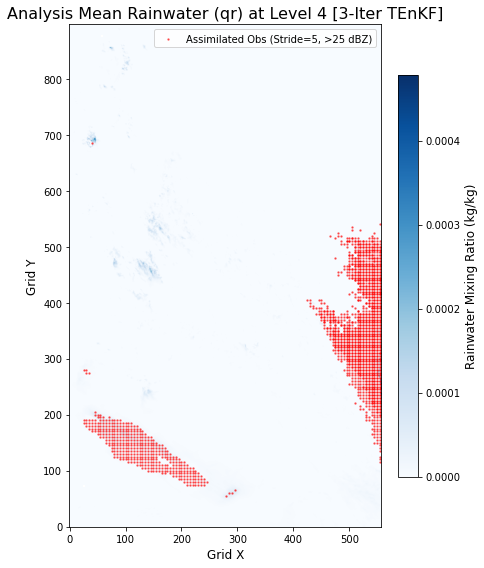

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuration
z_level = 4              # Choose a vertical level (e.g., 4)
qr_idx = VAR_IDX['qr']*1000   # Rainwater mixing ratio

# 2. Extract the Analysis Mean
# Slice shape: (nx, ny, Ne) -> mean across Ne (axis 2) -> (nx, ny)
xa_qr_mean = d3['xa'][:, :, z_level, :, qr_idx].mean(axis=-1)

# 3. Create the Spatial Plot
fig, ax = plt.subplots(figsize=(12, 8))

# WRF arrays are usually (x, y), so we transpose (.T) for standard (y, x) map orientation
im = ax.imshow(xa_qr_mean.T, origin='lower', cmap='Blues', vmin=0)

# Overlay the exact 1,893 observation points that survived the QC filter
ax.scatter(ox, oy, color='red', s=2, alpha=0.5, label='Assimilated Obs (Stride=5, >25 dBZ)')

# Formatting
ax.set_title(f'Analysis Mean Rainwater (qr) at Level {z_level} [3-Iter TEnKF]', fontsize=16)
ax.set_xlabel('Grid X', fontsize=12)
ax.set_ylabel('Grid Y', fontsize=12)
ax.legend(loc='upper right')

# Add colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Rainwater Mixing Ratio (kg/kg)', fontsize=12)

plt.tight_layout()
plt.show()

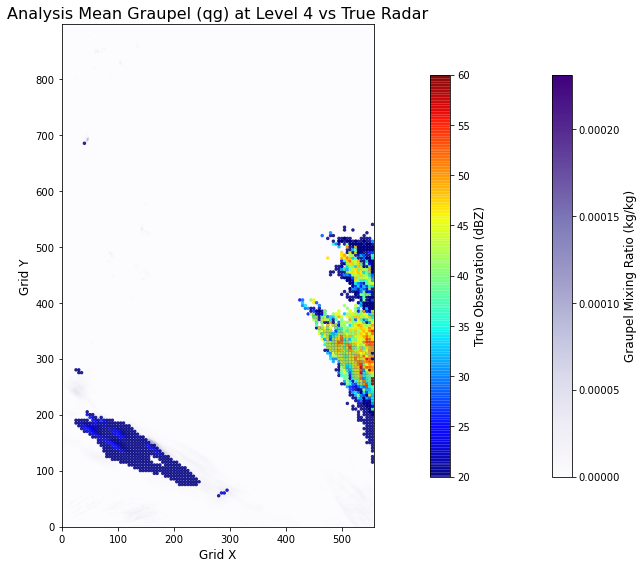

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Switch to Graupel!
z_level = 4              
qg_idx = VAR_IDX['qg']   # Graupel mixing ratio

# 2. Extract the Analysis Mean for Graupel
xa_qg_mean = d3['xa'][:, :, z_level, :, qg_idx].mean(axis=-1)

# 3. Create the Spatial Plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the Graupel field
im = ax.imshow(xa_qg_mean.T, origin='lower', cmap='Purples', vmin=0)

# Overlay the Observations, but color them by the TRUE reflectivity (yo)
sc = ax.scatter(ox, oy, c=d1['yo'], cmap='jet', s=6, alpha=0.8, vmin=20, vmax=60)

# Formatting
ax.set_title(f'Analysis Mean Graupel (qg) at Level {z_level} vs True Radar', fontsize=16)
ax.set_xlabel('Grid X', fontsize=12)
ax.set_ylabel('Grid Y', fontsize=12)

# Add colorbars
cbar_qg = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar_qg.set_label('Graupel Mixing Ratio (kg/kg)', fontsize=12)

cbar_obs = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.08)
cbar_obs.set_label('True Observation (dBZ)', fontsize=12)

plt.tight_layout()
plt.show()